# EMNIST Character Classification using HOG + SVM + LOOCV

Nama: Said Muhammad Ridho Oktafiandra
 
NIM: 4222301066

Metode:
- HOG (Histogram of Oriented Gradients)
- SVM (Support Vector Machine)
- Leave-One-Out Cross Validation (LOOCV)

Dataset:
EMNIST Balanced Dataset

In [9]:
!pip3 install matplotlib numpy seaborn scikit-learn scikit-image mlxtend

# 2. Dataset Preparation

Import library yang diperlukan untuk proses klasifikasi EMNIST.


### Penjelasan
Cell ini digunakan untuk mengimpor library yang diperlukan


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    f1_score
)


To confirm whether the dataset already downloaded, use this following command

### Penjelasan
Cell ini digunakan untuk membaca atau memuat dataset.


In [11]:
data = pd.read_csv(
    r"archive (1)/emnist-letters-train.csv",
    header=None
)

data_labels = data.iloc[:, 0].values
data_img = data.iloc[:, 1:].values

print("Total images:", len(data_img))
print("Total labels:", len(data_labels))

Total images: 88800
Total labels: 88800


### Penjelasan
Cell ini digunakan untuk visualisasi gambar atau grafik.


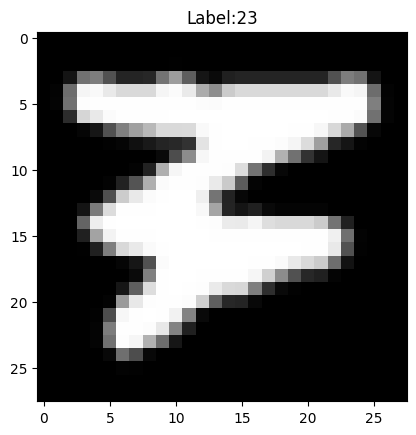

In [12]:
plt.imshow(
data_img[0].reshape(28,28),
cmap="gray"
)

plt.title(
f"Label:{data_labels[0]}"
)

plt.show()

### Penjelasan
Kode ini digunakan untuk:

Menyesuaikan label dataset.

Mengubah data menjadi format NumPy array.

Menyiapkan variabel kosong untuk menyimpan data yang akan dipilih atau diproses lebih lanjut


In [13]:
data_labels=data_labels-1

data_img=np.array(data_img)

data_labels=np.array(data_labels)

selected_img=[]

selected_labels=[]

### Penjelasan
Kode ini digunakan untuk:

Mengambil data dari setiap huruf A–Z.

Memilih 100 gambar secara acak dari tiap huruf.

Menyimpan gambar dan label yang dipilih.

Membuat dataset yang seimbang untuk training machine learning.


In [14]:
for class_idx in range(26):

    idx=np.where(
        data_labels==class_idx
    )[0]

    if len(idx)>=100:

        selected_idx=np.random.choice(
            idx,
            100,
            replace=False
        )

        selected_img.append(
            data_img[selected_idx]
        )

        selected_labels.append(
            data_labels[selected_idx]
        )

    else:

        print(
        f"Class {class_idx} only has {len(idx)}"
        )

### Penjelasan
x_subset shape: (2600, 784)
Artinya dataset gambar berhasil digabung menjadi 2600 gambar, dan setiap gambar memiliki 784 fitur/pixel.
Angka 784 berasal dari ukuran gambar 28 × 28 = 784 pixel.

y_subset shape: (2600,)
Artinya terdapat 2600 label yang sesuai dengan 2600 gambar tadi.
Setiap gambar punya 1 label huruf.


In [15]:
X_subset=np.vstack(
selected_img
)

y_subset=np.hstack(
selected_labels
)

print(
"x_subset shape:",
X_subset.shape
)

print(
"y_subset shape:",
y_subset.shape
)

x_subset shape: (2600, 784)
y_subset shape: (2600,)


### Penjelasan
Cell ini digunakan untuk mengimpor library yang diperlukan.


In [16]:
# Cek apakah data sudah ada
print("X_subset:", X_subset.shape)
print("y_subset:", y_subset.shape)

# Split data train dan test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_subset,
    y_subset,
    test_size=0.2,
    random_state=42,
    stratify=y_subset
)

print("x_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("x_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_subset: (2600, 784)
y_subset: (2600,)
x_train shape: (2080, 784)
y_train shape: (2080,)
x_test shape: (520, 784)
y_test shape: (520,)


# 3. Feature Extraction using HOG

### Penjelasan
Cell ini digunakan untuk ekstraksi fitur gambar menggunakan metode HOG.


In [17]:
feature,hog_img=hog(

X_train[0].reshape(28,28),

orientations=8,

pixels_per_cell=(4,4),

cells_per_block=(2,2),

visualize=True,

block_norm='L2'

)

feature.shape

(1152,)

### Penjelasan
Cell ini digunakan untuk ekstraksi fitur gambar menggunakan metode HOG.


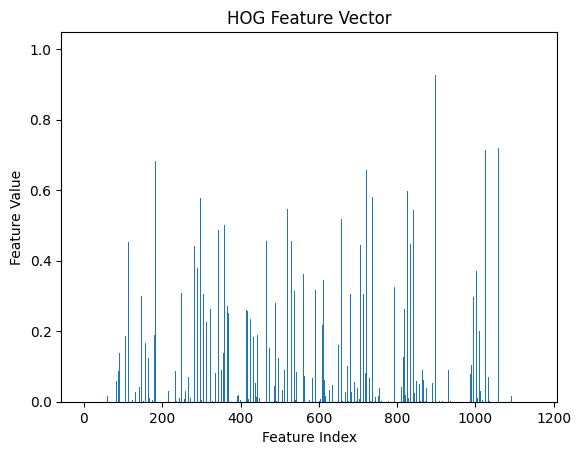

In [18]:
plt.bar(
list(range(feature.shape[0])),
feature
)

plt.title(
"HOG Feature Vector"
)

plt.xlabel(
"Feature Index"
)

plt.ylabel(
"Feature Value"
)

plt.show()

### Penjelasan
Cell ini digunakan untuk mengimpor library yang diperlukan.


In [19]:
from skimage.feature import hog
import numpy as np

def hog_features(
    images,
    orientations=8,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2)
):
    
    features=[]

    for img in images:

        feature=hog(
            img.reshape(28,28),
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm='L2'
        )

        features.append(feature)

    return np.array(features)

### Penjelasan
Cell ini digunakan untuk ekstraksi fitur gambar menggunakan metode HOG.


In [20]:
orientations=8

pixels_per_cell=(4,4)

cells_per_block=(2,2)

X_train_hog = hog_features(
    X_train,
    orientations,
    pixels_per_cell,
    cells_per_block
)

X_test_hog = hog_features(
    X_test,
    orientations,
    pixels_per_cell,
    cells_per_block
)

print(
    "HOG feature shape training:",
    X_train_hog.shape
)

print(
    "HOG feature shape testing:",
    X_test_hog.shape
)

HOG feature shape training: (2080, 1152)
HOG feature shape testing: (520, 1152)


3. Classification using SVM
Parameter tuning using GridSearchCV

### Penjelasan
Cell ini digunakan untuk mengimpor library yang diperlukan.


In [21]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svm = SVC()

grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    X_train_hog,
    y_train
)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

### Penjelasan
Cell ini digunakan untuk ekstraksi fitur gambar menggunakan metode HOG.


In [22]:
print(
    "Best parameters found:",
    grid_search.best_params_
)

print(
    "Performance:",
    grid_search.best_estimator_.score(
        X_test_hog,
        y_test
    )
)

best_model = grid_search.best_estimator_

Best parameters found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Performance: 0.8365384615384616


4. Evaluation

### Penjelasan
Cell ini digunakan untuk mengimpor library yang diperlukan.


In [23]:
from sklearn.metrics import (
    classification_report,
    accuracy_score
)

y_test_pred = best_model.predict(
    X_test_hog
)

print(
    "---Test Set Evaluation---"
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_test_pred
    )
)

print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_test,
        y_test_pred
    )
)

---Test Set Evaluation---
Accuracy: 0.8365384615384616

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.65      0.72        20
           1       0.95      0.90      0.92        20
           2       0.90      0.95      0.93        20
           3       0.95      0.90      0.92        20
           4       0.90      0.90      0.90        20
           5       0.82      0.90      0.86        20
           6       0.65      0.75      0.70        20
           7       0.93      0.65      0.76        20
           8       0.60      0.45      0.51        20
           9       0.83      0.75      0.79        20
          10       0.87      1.00      0.93        20
          11       0.47      0.70      0.56        20
          12       0.89      0.85      0.87        20
          13       0.82      0.90      0.86        20
          14       0.83      0.95      0.88        20
          15       0.95      0.90      0.92        20
 

### Penjelasan
Cell ini digunakan untuk mengimpor library yang diperlukan.


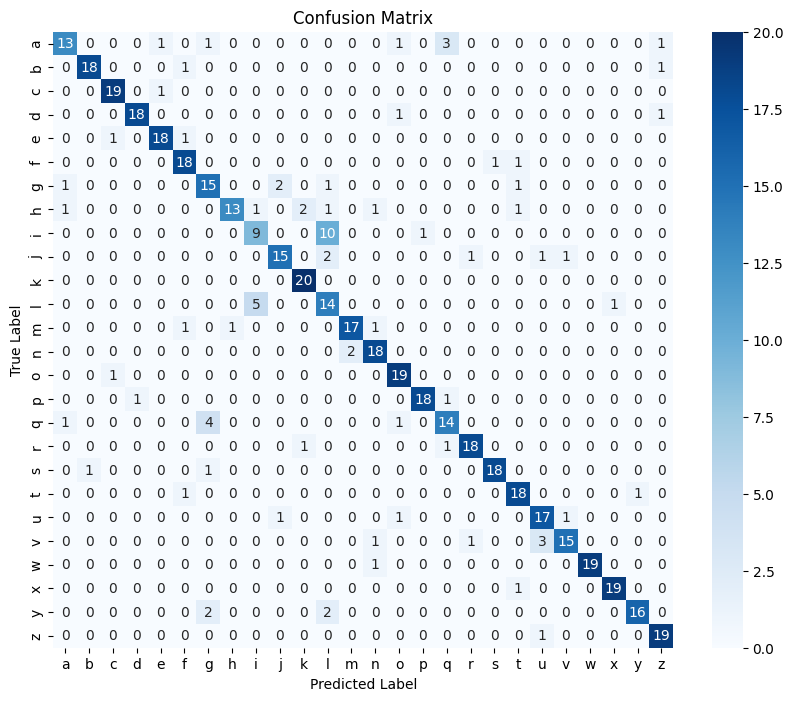

In [24]:
from sklearn.metrics import confusion_matrix

c_mat = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    c_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[chr(i+97) for i in range(26)],
    yticklabels=[chr(i+97) for i in range(26)]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

5. Prediction Results


### Penjelasan
Cell ini digunakan untuk mengimpor library yang diperlukan.


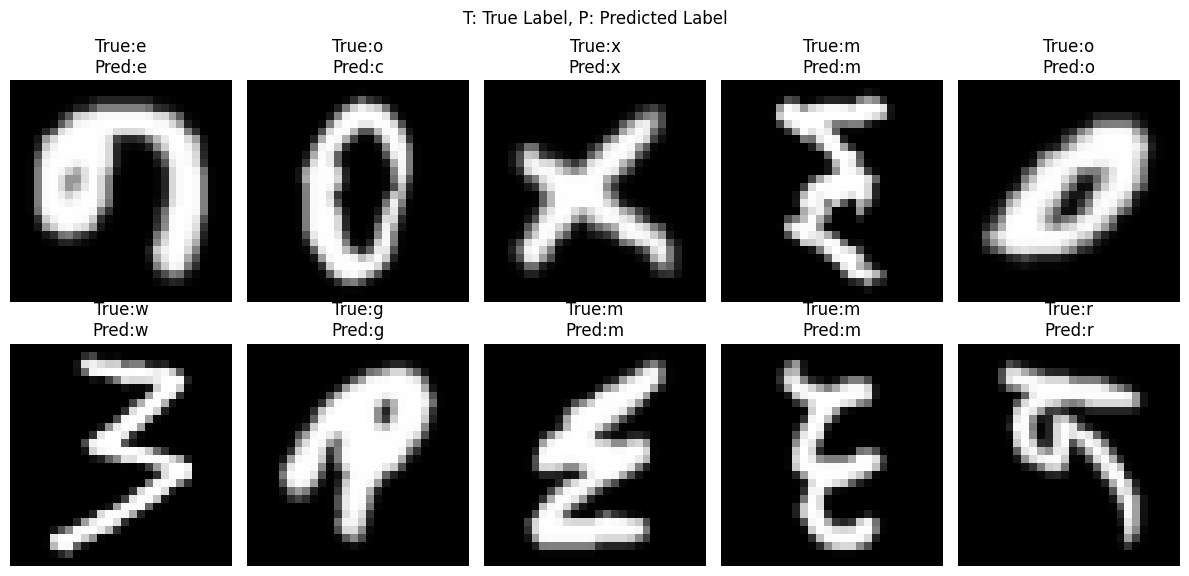

In [25]:
import random

indices = random.sample(
    range(len(X_test)),
    10
)

plt.figure(figsize=(12,6))

for i, idx in enumerate(indices):

    img = X_test[idx].reshape(28,28)

    true_label = y_test[idx]

    pred_label = y_test_pred[idx]

    plt.subplot(
        2,
        5,
        i+1
    )

    plt.imshow(
        img,
        cmap='gray'
    )

    plt.title(
        f"True:{chr(true_label+97)}\nPred:{chr(pred_label+97)}"
    )

    plt.axis(
        'off'
    )

plt.suptitle(
    "T: True Label, P: Predicted Label"
)

plt.tight_layout()

plt.show()